# 1D Serial vs MPI

This notebook launches the MPI example script with `mpirun`, then loads the saved outputs to compare the legacy and MPI implementations.

In [1]:
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
OUT = ROOT / "examples" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)


In [2]:
cmd = [
    "mpirun",
    "-launcher",
    "fork",
    "-n",
    "2",
    "python",
    str(ROOT / "examples/python_scripts/ex_1d_mpi_compare.py"),
    "--output-dir",
    str(OUT),
]
completed = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True, check=True)
print(completed.stdout)


SF_LL: max abs diff = 0.000e+00
SF_LLL: max abs diff = 0.000e+00
SF_LTT: max abs diff = 0.000e+00
SF_LSS: max abs diff = 0.000e+00
Saved outputs to /Users/victorzendejaslopez/Documents/fluidsf/examples/outputs



SF_LL 0.0
SF_LLL 0.0
SF_LTT 0.0
SF_LSS 0.0


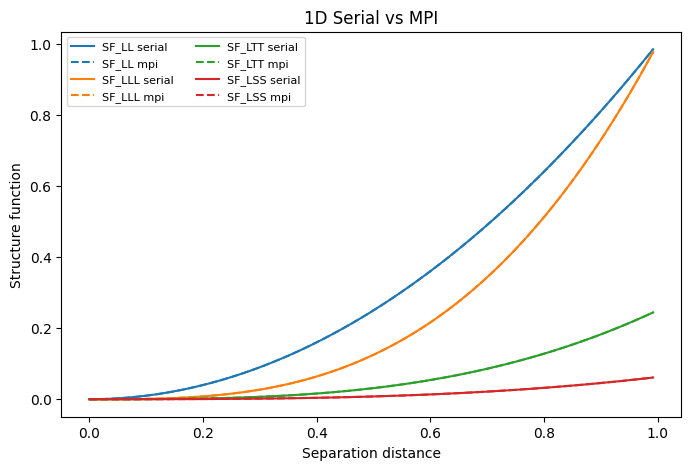

In [3]:
data = np.load(OUT / "ex_1d_mpi_compare.npz")
for name in ["SF_LL", "SF_LLL", "SF_LTT", "SF_LSS"]:
    diff = np.max(np.abs(data[f"serial_{name}"] - data[f"mpi_{name}"]))
    print(name, diff)

fig, ax = plt.subplots(figsize=(8, 5))
for name, color in zip(["SF_LL", "SF_LLL", "SF_LTT", "SF_LSS"], ["C0", "C1", "C2", "C3"]):
    ax.plot(data["x_diffs"], data[f"serial_{name}"], color=color, linestyle="-", label=f"{name} serial")
    ax.plot(data["x_diffs"], data[f"mpi_{name}"], color=color, linestyle="--", label=f"{name} mpi")
ax.set_xlabel("Separation distance")
ax.set_ylabel("Structure function")
ax.legend(ncol=2, fontsize=8)
ax.set_title("1D Serial vs MPI")
plt.show()
